# HLT Project: Task-Specific Deception Classifier

## Objective

Train and evaluate a task-specific transformer classifier for truthful vs. deceptive hotel reviews.

We fine-tune **RoBERTa-base** using the labeled training portion of the Positive Deceptive Opinion Spam Corpus.

Evaluation follows the corpus's original five hotel-based folds. For each fold:

- four folds are used for training;
- the remaining fold is used exclusively for testing;
- the procedure is repeated until every review has received one out-of-fold prediction.

This produces predictions for all 800 reviews while preventing reviews from the same held-out hotels from appearing in both training and test data.

The resulting task-specific classifier will later be compared with the zero-shot LLM evaluated on the same corpus.

In [ ]:
!pip -q install -U datasets pyarrow transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 68.4 MB/s eta 0:00:00


In [ ]:
import transformers
import datasets
import torch

print(transformers.__version__)
print(datasets.__version__)
print(torch.__version__)

## 1. Project Setup and Load the Dataset

In [ ]:
from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np
import random
import torch


drive.mount("/content/drive")


RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


PROJECT_DIR = Path(
    "/content/drive/MyDrive/HLT_project"
)

DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed"
)

RESULTS_DIR = (
    PROJECT_DIR /
    "results"
)

FIGURES_DIR = (
    PROJECT_DIR /
    "figures"
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


DATASET_PATH = (
    DATA_DIR /
    "positive_deceptive_reviews_clean.csv"
)


df_clean = pd.read_csv(
    DATASET_PATH
)


print(
    "Dataset shape:",
    df_clean.shape
)

display(
    df_clean.head()
)

Mounted at /content/drive
Dataset shape: (800, 8)


,review_id,text,label,hotel,fold,source,n_words,n_characters
0,R0000,We stayed for a one night getaway with family ...,truthful,conrad,fold3,TripAdvisor,105,572
1,R0001,Triple A rate with upgrade to view room was le...,truthful,hyatt,fold3,TripAdvisor,45,286
2,R0002,This comes a little late as I'm finally catchi...,truthful,hyatt,fold3,TripAdvisor,207,1104
3,R0003,The Omni Chicago really delivers on all fronts...,truthful,omni,fold3,TripAdvisor,127,707
4,R0004,I asked for a high floor away from the elevato...,truthful,hyatt,fold3,TripAdvisor,72,384


## 2. Verify Labels and Original Folds

In [ ]:
print("LABEL DISTRIBUTION")

print(
    df_clean[
        "label"
    ].value_counts()
)


print("\nFOLD DISTRIBUTION")

print(
    df_clean[
        "fold"
    ].value_counts()
)


print("\nFOLD × LABEL")

display(
    pd.crosstab(
        df_clean["fold"],
        df_clean["label"]
    )
)

LABEL DISTRIBUTION
label
truthful     400
deceptive    400
Name: count, dtype: int64

FOLD DISTRIBUTION
fold
fold3    160
fold4    160
fold2    160
fold1    160
fold5    160
Name: count, dtype: int64

FOLD × LABEL


label,deceptive,truthful
fold,,
fold1,80,80
fold2,80,80
fold3,80,80
fold4,80,80
fold5,80,80


## 3. Check the Colab GPU


In [ ]:
print(
    "CUDA available:",
    torch.cuda.is_available()
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA available: True
GPU: Tesla T4


# 4. Load the RoBERTa Tokenizer

**RoBERTa-base** is used as the task-specific transformer baseline.

Unlike the zero-shot LLM , RoBERTa will be fine-tuned directly on labeled examples from the deception corpus.

Before choosing the maximum sequence length, we look at how long the reviews are (in tokens) to see how much text would be cut off at different limits.

In [ ]:
from transformers import AutoTokenizer


MODEL_NAME = "FacebookAI/roberta-base"


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


print(
    "Tokenizer loaded:",
    MODEL_NAME
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer loaded: FacebookAI/roberta-base


## 5. Inspect Review Length in RoBERTa Tokens

Review length was previously analyzed in words. For transformer training, however, sequence length is determined by the model tokenizer.

We therefore inspect the number of RoBERTa tokens per review before choosing the maximum input length.

In [ ]:

token_lengths = []


for text in df_clean["text"]:

    tokens = tokenizer(
        text,
        add_special_tokens=True,
        truncation=False
    )

    token_lengths.append(
        len(
            tokens["input_ids"]
        )
    )


df_clean["n_roberta_tokens"] = (
    token_lengths
)


print(
    df_clean[
        "n_roberta_tokens"
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


print(
    "\nReviews longer than 256 tokens:",
    (
        df_clean[
            "n_roberta_tokens"
        ] > 256
    ).sum()
)


print(
    "Reviews longer than 512 tokens:",
    (
        df_clean[
            "n_roberta_tokens"
        ] > 512
    ).sum()
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (533 > 512). Running this sequence through the model will result in indexing errors


count    800.000000
mean     145.436250
std       77.104798
min       32.000000
50%      128.000000
75%      176.000000
90%      234.200000
95%      297.000000
99%      420.070000
max      533.000000
Name: n_roberta_tokens, dtype: float64

Reviews longer than 256 tokens: 65
Reviews longer than 512 tokens: 2


## 6. Select the Maximum Sequence Length

RoBERTa supports sequences of up to 512 tokens.

Only 2 of the 800 reviews (0.25%) exceed this limit, whereas using a 256-token limit would truncate 65 reviews (8.1% of the corpus).

The maximum sequence length is therefore set to 512 tokens, since the dataset is small and truncating 65 reviews — more than 8% of the corpus — just to save computation is undesirable. Reviews exceeding this limit are truncated..

In [ ]:
MAX_LENGTH = 512

## 7. Encode the Class Labels

The textual labels are converted into integer class IDs required by the sequence-classification model.

- truthful → 0
- deceptive → 1

In [ ]:
LABEL2ID = {"truthful": 0, "deceptive": 1}
ID2LABEL = {0: "truthful", 1: "deceptive"}

df_clean["label_id"] = df_clean["label"].map(LABEL2ID)

print(df_clean[["label", "label_id"]].drop_duplicates().sort_values("label_id"))

         label  label_id
0     truthful         0
400  deceptive         1


## 8. Define the RoBERTa Tokenization Procedure

Each review is tokenized using the RoBERTa tokenizer.

Sequences longer than 512 tokens are truncated. Padding is not applied at this stage, in order to avoid wasting memory, instead it will be applied dynamically per batch.


In [ ]:
def tokenize_reviews(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

This function will receive multiple reviews at once thanks to: batched=True



## 9. Testing the First Hotel-Based Cross-Validation Split

As a sanity check, the complete training and prediction pipeline is first tested using fold1 as the held-out test set.

All reviews from fold1 are excluded from training.

Because the original folds are defined at the hotel level, the hotels appearing in the test set must not appear in the training set.

In [ ]:
TEST_FOLD = "fold1"


train_df = df_clean[
    df_clean["fold"] != TEST_FOLD
].copy()


test_df = df_clean[
    df_clean["fold"] == TEST_FOLD
].copy()


print(
    "Training reviews:",
    len(train_df)
)

print(
    "Test reviews:",
    len(test_df)
)


print(
    "\nTraining label distribution:"
)

print(
    train_df[
        "label"
    ].value_counts()
)


print(
    "\nTest label distribution:"
)

print(
    test_df[
        "label"
    ].value_counts()
)

Training reviews: 640
Test reviews: 160

Training label distribution:
label
truthful     320
deceptive    320
Name: count, dtype: int64

Test label distribution:
label
truthful     80
deceptive    80
Name: count, dtype: int64


## 10. Verify Hotel Separation Between Training and Test Sets

The original folds are hotel-based.

We explicitly verify that no hotel in the held-out test fold appears in the training data, preventing hotel-specific information from leaking across the split.

In [ ]:
train_hotels = set(
    train_df["hotel"]
)


test_hotels = set(
    test_df["hotel"]
)


hotel_overlap = (
    train_hotels
    .intersection(
        test_hotels
    )
)


print(
    "Training hotels:",
    len(train_hotels)
)

print(
    "Test hotels:",
    len(test_hotels)
)

print(
    "Hotels appearing in both sets:",
    hotel_overlap
)

Training hotels: 16
Test hotels: 4
Hotels appearing in both sets: set()


## 11. Convert the Split into Transformer Datasets

The pandas training and test sets are converted into Hugging Face Dataset objects and tokenized using the procedure defined above.

Only the review text and numerical class label are required for model training.

In [ ]:
from datasets import Dataset


train_dataset = Dataset.from_pandas(
    train_df[
        [
            "text",
            "label_id"
        ]
    ],
    preserve_index=False
)


test_dataset = Dataset.from_pandas(
    test_df[
        [
            "text",
            "label_id"
        ]
    ],
    preserve_index=False
)


train_dataset = train_dataset.rename_column(
    "label_id",
    "labels"
)


test_dataset = test_dataset.rename_column(
    "label_id",
    "labels"
)


train_dataset = train_dataset.map(
    tokenize_reviews,
    batched=True
)


test_dataset = test_dataset.map(
    tokenize_reviews,
    batched=True
)


print(
    train_dataset
)

print(
    test_dataset
)

Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 640
})
Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 160
})


## 12. Define Dynamic Batch Padding



In [ ]:
from transformers import DataCollatorWithPadding


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

## 13. Initialize the RoBERTa Sequence Classifier

A fresh RoBERTa-base model is initialized for binary sequence classification.

The pretrained language representations are retained, while a new two-class classification head is added and fine-tuned on the deception corpus.

A fresh model will later be initialized independently for each cross-validation fold.

In [ ]:
from transformers import AutoModelForSequenceClassification

# Carica il modello pre-addestrato e lo adatta per una classificazione a 2 classi
# (truthful / deceptive), passando anche le mappe id<->label
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

print("Model loaded:", MODEL_NAME)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: FacebookAI/roberta-base


## 15. Define Classification Metrics

Performance is evaluated using:

- accuracy;
- precision;
- recall;
- F1-score;
- macro F1.

For the binary metrics, the deceptive class is treated as the positive class.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )


    accuracy = accuracy_score(
        labels,
        predictions
    )


    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary",
            pos_label=1,
            zero_division=0
        )
    )


    _, _, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )


    return {
        "accuracy": accuracy,
        "precision_deceptive": precision,
        "recall_deceptive": recall,
        "f1_deceptive": f1,
        "macro_f1": macro_f1
    }

## 16. Define Fixed Fine-Tuning Hyperparameters

To avoid tuning the model on the held-out test folds, the fine-tuning configuration is fixed before evaluation and kept identical across all five folds.

The test fold is never used for model selection or early stopping.

Configuration:

- epochs: 3
- learning rate: 2e-5
- training batch size: 8
- evaluation batch size: 8
- weight decay: 0.01

No evaluation is performed during training. Each held-out fold is used only after fine-tuning is complete.

In [ ]:
from transformers import TrainingArguments

# Cartella dove verranno salvati i risultati/checkpoint di questo fold
FOLD_OUTPUT_DIR = PROJECT_DIR / "models" / "roberta_fold1"

# Parametri di training per il fine-tuning del modello
training_args = TrainingArguments(
    output_dir=str(FOLD_OUTPUT_DIR),
    num_train_epochs=3,          # numero di epoche
    learning_rate=2e-5,          # tasso di apprendimento
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    eval_strategy="no",          # nessuna valutazione durante il training
    save_strategy="no",          # nessun salvataggio automatico dei checkpoint
    logging_strategy="epoch",    # log a fine epoca
    fp16=torch.cuda.is_available(),  # usa precisione mista se c'è la GPU
    seed=RANDOM_SEED,
    data_seed=RANDOM_SEED,
    report_to="none"             # disattiva l'invio dei log a servizi esterni
)

## 16. Create the RoBERTa Trainer

In [ ]:
from transformers import Trainer

# Crea il Trainer, l'oggetto che gestisce il ciclo di training/valutazione
trainer = Trainer(
    model=model,                      # il modello da addestrare
    args=training_args,               # i parametri di training definiti prima
    train_dataset=train_dataset,      # dati di training
    data_collator=data_collator,      # funzione che prepara i batch
    processing_class=tokenizer,       # tokenizer usato per il preprocessing
    compute_metrics=compute_metrics   # funzione per calcolare le metriche
)

## 17. Fine-Tune RoBERTa — Fold 1 Held Out

In [ ]:
trainer.train()

Step,Training Loss
80,0.533389
160,0.236572
240,0.153454


TrainOutput(global_step=240, training_loss=0.30780494610468545, metrics={'train_runtime': 34.8072, 'train_samples_per_second': 55.161, 'train_steps_per_second': 6.895, 'total_flos': 279271829713440.0, 'train_loss': 0.30780494610468545, 'epoch': 3.0})

## 18. Predict the Held-Out Fold

After fine-tuning on the four training folds, the model is evaluated once on the held-out fold.

These 160 reviews, corresponding to four unseen hotels, were never used during training.

In [ ]:
fold1_output = trainer.predict(
    test_dataset
)


print(
    "Prediction array shape:",
    fold1_output.predictions.shape
)

print(
    "Number of gold labels:",
    len(fold1_output.label_ids)
)

Prediction array shape: (160, 2)
Number of gold labels: 160


## 19. Convert RoBERTa Outputs into Class Predictions

In [ ]:
import torch


fold1_logits = (
    fold1_output.predictions
)


fold1_prediction_ids = np.argmax(
    fold1_logits,
    axis=1
)


fold1_probabilities = torch.softmax(
    torch.tensor(
        fold1_logits,
        dtype=torch.float32
    ),
    dim=1
).numpy()


fold1_predictions = [
    ID2LABEL[prediction_id]
    for prediction_id
    in fold1_prediction_ids
]


print(
    "Number of predictions:",
    len(fold1_predictions)
)


print(
    "\nPrediction distribution:"
)

print(
    pd.Series(
        fold1_predictions
    ).value_counts()
)

Number of predictions: 160

Prediction distribution:
deceptive    83
truthful     77
Name: count, dtype: int64


## 20. Evaluate Performance on Fold 1

Performance is measured only on the held-out reviews.

Because the test fold is balanced between truthful and deceptive reviews, we report overall accuracy together with class-specific precision, recall and F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Calcola l'accuratezza confrontando le etichette vere con le predizioni
fold1_accuracy = accuracy_score(test_df["label"], fold1_predictions)
print("Fold 1 accuracy:", round(fold1_accuracy, 4))

# Stampa il report dettagliato (precision, recall, f1) per ogni classe
print("\nCLASSIFICATION REPORT\n")
print(classification_report(
    test_df["label"],
    fold1_predictions,
    labels=["truthful", "deceptive"],
    digits=4,
    zero_division=0
))

Fold 1 accuracy: 0.8938

CLASSIFICATION REPORT

              precision    recall  f1-score   support

    truthful     0.9091    0.8750    0.8917        80
   deceptive     0.8795    0.9125    0.8957        80

    accuracy                         0.8938       160
   macro avg     0.8943    0.8938    0.8937       160
weighted avg     0.8943    0.8938    0.8937       160



## 21. Inspect the Fold 1 Confusion Table

In [ ]:
# Crea la matrice di confusione: righe = etichetta vera, colonne = predizione
fold1_confusion = pd.crosstab(
    test_df["label"],
    pd.Series(fold1_predictions, index=test_df.index),
    rownames=["Gold label"],
    colnames=["Prediction"]
)

display(fold1_confusion)

Prediction,deceptive,truthful
Gold label,,
deceptive,73,7
truthful,10,70


## 22. Build the Fold 1 Prediction Table

For every held-out review, we retain its identifier, gold label, predicted label and model probability.

These out-of-fold predictions will later be combined with the predictions from the remaining four folds.

In [ ]:
# Seleziona le colonne base e resetta l'indice
fold1_results_df = test_df[["review_id", "hotel", "fold", "label"]].copy()
fold1_results_df = fold1_results_df.reset_index(drop=True)
fold1_results_df = fold1_results_df.rename(columns={"label": "gold_label"})

# Aggiunge predizioni, probabilità per classe e flag di correttezza
fold1_results_df["prediction"] = fold1_predictions
fold1_results_df["p_truthful"] = fold1_probabilities[:, 0]
fold1_results_df["p_deceptive"] = fold1_probabilities[:, 1]
fold1_results_df["correct"] = fold1_results_df["gold_label"] == fold1_results_df["prediction"]

display(fold1_results_df.head())

,review_id,hotel,fold,gold_label,prediction,p_truthful,p_deceptive,correct
0,R0240,hilton,fold1,truthful,truthful,0.998469,0.001531,True
1,R0241,hilton,fold1,truthful,truthful,0.998573,0.001427,True
2,R0242,james,fold1,truthful,deceptive,0.343975,0.656025,False
3,R0243,hilton,fold1,truthful,truthful,0.998469,0.001531,True
4,R0244,james,fold1,truthful,deceptive,0.000938,0.999062,False


In [ ]:
FOLD1_RESULTS_PATH = (
    RESULTS_DIR /
    "roberta_fold1_predictions.csv"
)


fold1_results_df.to_csv(
    FOLD1_RESULTS_PATH,
    index=False
)


print(
    "Fold 1 results saved at:"
)

print(
    FOLD1_RESULTS_PATH
)

Fold 1 results saved at:
/content/drive/MyDrive/HLT_project/results/roberta_fold1_predictions.csv


## 24. Define the Hotel-Fold Training and Evaluation Procedure

The same training and evaluation procedure is applied independently to each remaining fold.

For every fold:

1. the selected fold is held out as the test set;
2. the other four folds are used for fine-tuning;
3. a fresh RoBERTa-base classifier is initialized;
4. the fixed hyperparameters are used without modification;
5. predictions are generated only after training is complete;
6. review-level predictions are saved to persistent storage.

A fresh model is initialized for every fold to prevent information from carrying over between cross-validation iterations.

In [ ]:
import gc

from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)


def run_roberta_fold(test_fold):

    print("\n========================================")
    print("HELD-OUT FOLD:", test_fold)
    print("========================================\n")


    # --------------------------------------------------
    # 1. Dividiamo i dati in training e test
    # --------------------------------------------------

    # Tutti i fold tranne test_fold vengono usati per il training
    train_df_fold = df_clean[
        df_clean["fold"] != test_fold
    ].copy()

    # Il fold scelto viene usato come test set
    test_df_fold = df_clean[
        df_clean["fold"] == test_fold
    ].copy()

    print("Training reviews:", len(train_df_fold))
    print("Test reviews:", len(test_df_fold))


    # --------------------------------------------------
    # 2. Convertiamo i dataframe in Hugging Face Dataset
    # --------------------------------------------------

    # Per il modello servono solamente testo e label
    train_dataset_fold = Dataset.from_pandas(
        train_df_fold[["text", "label_id"]],
        preserve_index=False
    )

    test_dataset_fold = Dataset.from_pandas(
        test_df_fold[["text", "label_id"]],
        preserve_index=False
    )

    # Hugging Face si aspetta che la colonna delle label
    # si chiami "labels"
    train_dataset_fold = train_dataset_fold.rename_column(
        "label_id",
        "labels"
    )

    test_dataset_fold = test_dataset_fold.rename_column(
        "label_id",
        "labels"
    )

    # Tokenizziamo tutte le recensioni
    train_dataset_fold = train_dataset_fold.map(
        tokenize_reviews,
        batched=True
    )

    test_dataset_fold = test_dataset_fold.map(
        tokenize_reviews,
        batched=True
    )


    # --------------------------------------------------
    # 3. Creiamo un nuovo modello per questo fold
    # --------------------------------------------------

    # Impostiamo il seed per rendere i risultati riproducibili
    set_seed(RANDOM_SEED)

    fold_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )


    # --------------------------------------------------
    # 4. Impostazioni del training
    # --------------------------------------------------

    fold_output_dir = PROJECT_DIR / "models" / f"roberta_{test_fold}"

    fold_training_args = TrainingArguments(
        output_dir=str(fold_output_dir),

        num_train_epochs=3,
        learning_rate=2e-5,

        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,

        weight_decay=0.01,

        # Non facciamo evaluation durante il training
        eval_strategy="no",

        # Non salviamo checkpoint intermedi
        save_strategy="no",

        # Stampiamo i log alla fine di ogni epoca
        logging_strategy="epoch",

        # Usa fp16 solamente se è disponibile una GPU CUDA
        fp16=torch.cuda.is_available(),

        seed=RANDOM_SEED,
        data_seed=RANDOM_SEED,

        report_to="none"
    )


    # --------------------------------------------------
    # 5. Creiamo il Trainer
    # --------------------------------------------------

    fold_trainer = Trainer(
        model=fold_model,
        args=fold_training_args,
        train_dataset=train_dataset_fold,
        data_collator=data_collator,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )


    # --------------------------------------------------
    # 6. Fine-tuning del modello
    # --------------------------------------------------

    fold_trainer.train()


    # --------------------------------------------------
    # 7. Facciamo le predizioni sul fold lasciato fuori
    # --------------------------------------------------

    fold_output = fold_trainer.predict(test_dataset_fold)

    # Output grezzo del modello
    logits = fold_output.predictions

    # Per ogni recensione prendiamo la classe
    # con il logit più alto
    prediction_ids = np.argmax(logits, axis=1)

    # Convertiamo i logits in probabilità
    probabilities = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=1
    ).numpy()

    # Convertiamo gli ID delle classi nei nomi delle label
    predictions = [
        ID2LABEL[prediction_id]
        for prediction_id in prediction_ids
    ]


    # --------------------------------------------------
    # 8. Creiamo il dataframe con i risultati
    # --------------------------------------------------

    results_df = test_df_fold[
        ["review_id", "hotel", "fold", "label"]
    ].copy()

    results_df = results_df.reset_index(drop=True)

    # Rinominiamo la label vera per distinguerla
    # dalla predizione del modello
    results_df = results_df.rename(
        columns={"label": "gold_label"}
    )

    # Aggiungiamo la classe predetta
    results_df["prediction"] = predictions

    # Aggiungiamo le probabilità delle due classi
    results_df["p_truthful"] = probabilities[:, 0]
    results_df["p_deceptive"] = probabilities[:, 1]

    # True se la predizione è corretta, False altrimenti
    results_df["correct"] = (
        results_df["gold_label"] == results_df["prediction"]
    )


    # --------------------------------------------------
    # 9. Calcoliamo l'accuracy del fold
    # --------------------------------------------------

    fold_accuracy = results_df["correct"].mean()

    print(
        "\n",
        test_fold,
        "accuracy:",
        round(fold_accuracy, 4)
    )


    # --------------------------------------------------
    # 10. Salviamo le predizioni
    # --------------------------------------------------

    fold_results_path = (
        RESULTS_DIR / f"roberta_{test_fold}_predictions.csv"
    )

    results_df.to_csv(
        fold_results_path,
        index=False
    )

    print("Predictions saved:", fold_results_path)


    # --------------------------------------------------
    # 11. Liberiamo la memoria
    # --------------------------------------------------

    del fold_trainer
    del fold_model
    del train_dataset_fold
    del test_dataset_fold
    del fold_output

    gc.collect()

    # Se stiamo usando la GPU, svuotiamo anche la memoria CUDA
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # Restituiamo le predizioni di questo fold
    return results_df

In [ ]:
folds = [
    "fold1",
    "fold2",
    "fold3",
    "fold4",
    "fold5"
]


for test_fold in folds:

    fold_results_path = (
        RESULTS_DIR /
        f"roberta_{test_fold}_predictions.csv"
    )


    if fold_results_path.exists():

        print(
            f"{test_fold}: already completed — skipping."
        )

        continue


    print(
        f"\n{test_fold}: starting training..."
    )


    run_roberta_fold(
        test_fold
    )

fold1: already completed — skipping.

fold2: starting training...

HELD-OUT FOLD: fold2

Training reviews: 640
Test reviews: 160


Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
80,0.578025
160,0.235476
240,0.117513



 fold5 accuracy: 0.9438
Predictions saved: /content/drive/MyDrive/HLT_project/results/roberta_fold5_predictions.csv


In [ ]:
for fold_number in range(1, 6):

    path = (
        RESULTS_DIR /
        f"roberta_fold{fold_number}_predictions.csv"
    )

    print(
        f"fold{fold_number}:",
        "OK" if path.exists()
        else "MISSING"
    )

fold1: OK
fold2: OK
fold3: OK
fold4: OK
fold5: OK


## 25. Combine All Out-of-Fold RoBERTa Predictions

The predictions from all five held-out folds are combined.

Because every review belongs to exactly one test fold, the resulting table contains one out-of-fold prediction for each of the 800 corpus reviews.

In [ ]:
saved_fold_files = sorted(
    RESULTS_DIR.glob(
        "roberta_fold*_predictions.csv"
    )
)


print("Saved prediction files:\n")

for file in saved_fold_files:
    print(file.name)

Saved prediction files:

roberta_fold1_predictions.csv
roberta_fold2_predictions.csv
roberta_fold3_predictions.csv
roberta_fold4_predictions.csv
roberta_fold5_predictions.csv


In [ ]:
# Leggiamo i risultati del primo fold
fold1_results_df = pd.read_csv(
    RESULTS_DIR / "roberta_fold1_predictions.csv"
)

# Lista che conterrà i risultati di tutti i fold
all_roberta_results = [fold1_results_df]


# Leggiamo i risultati dei fold da 2 a 5
for fold_number in range(2, 6):

    fold_results_df = pd.read_csv(
        RESULTS_DIR / f"roberta_fold{fold_number}_predictions.csv"
    )

    all_roberta_results.append(fold_results_df)


# Uniamo tutti i fold in un unico dataframe
roberta_results_df = pd.concat(
    all_roberta_results,
    ignore_index=True
)


# Controlliamo che tutte le predizioni siano presenti
print("Total predictions:", len(roberta_results_df))

print(
    "Unique review IDs:",
    roberta_results_df["review_id"].nunique()
)

print(
    "Duplicate review IDs:",
    roberta_results_df["review_id"].duplicated().sum()
)


# Numero di predizioni per ogni fold
print("\nPredictions per fold:")

print(
    roberta_results_df["fold"]
    .value_counts()
    .sort_index()
)

Total predictions: 800
Unique review IDs: 800
Duplicate review IDs: 0

Predictions per fold:
fold
fold1    160
fold2    160
fold3    160
fold4    160
fold5    160
Name: count, dtype: int64


In [ ]:
# Percorso del file finale con tutte le predizioni RoBERTa
ROBERTA_RESULTS_PATH = (
    RESULTS_DIR / "roberta_5fold_out_of_fold_predictions.csv"
)

# Salviamo tutti i risultati in un file CSV
roberta_results_df.to_csv(
    ROBERTA_RESULTS_PATH,
    index=False
)

# Stampiamo il percorso del file salvato
print("Complete RoBERTa results saved at:")
print(ROBERTA_RESULTS_PATH)

Complete RoBERTa results saved at:
/content/drive/MyDrive/HLT_project/results/roberta_5fold_out_of_fold_predictions.csv


## 26. Verify the Complete Out-of-Fold Predictions

The predictions obtained from the five held-out folds are combined into a single dataset.

Each of the 800 reviews must appear exactly once, ensuring that every prediction was produced by a model that did not train on that review or its hotel fold.

In [ ]:
# Statistiche generali sul dataset di risultati
print("Total predictions:", len(roberta_results_df))
print("Unique review IDs:", roberta_results_df["review_id"].nunique())
print("Duplicate review IDs:", roberta_results_df["review_id"].duplicated().sum())
print("Missing predictions:", roberta_results_df["prediction"].isna().sum())

# Distribuzione delle etichette vere e delle predizioni
print("\nGold labels:")
print(roberta_results_df["gold_label"].value_counts())

print("\nPredictions:")
print(roberta_results_df["prediction"].value_counts())

Total predictions: 800
Unique review IDs: 800
Duplicate review IDs: 0
Missing predictions: 0

Gold labels:
gold_label
truthful     400
deceptive    400
Name: count, dtype: int64

Predictions:
prediction
deceptive    412
truthful     388
Name: count, dtype: int64


## 27. Evaluate Overall RoBERTa Performance

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Calcola l'accuratezza complessiva del modello RoBERTa
roberta_accuracy = accuracy_score(roberta_results_df["gold_label"], roberta_results_df["prediction"])
print("Overall RoBERTa accuracy:", round(roberta_accuracy, 4))

# Stampa il report dettagliato (precision, recall, f1) per ogni classe
print("\nCLASSIFICATION REPORT\n")
print(classification_report(
    roberta_results_df["gold_label"],
    roberta_results_df["prediction"],
    labels=["truthful", "deceptive"],
    digits=4,
    zero_division=0
))

Overall RoBERTa accuracy: 0.9375

CLASSIFICATION REPORT

              precision    recall  f1-score   support

    truthful     0.9510    0.9225    0.9365       400
   deceptive     0.9248    0.9525    0.9384       400

    accuracy                         0.9375       800
   macro avg     0.9379    0.9375    0.9375       800
weighted avg     0.9379    0.9375    0.9375       800



## 28.  Overall RoBERTa Confusion Table

In [ ]:
# Crea la matrice di confusione: righe = etichetta vera, colonne = predizione
roberta_confusion = pd.crosstab(
    roberta_results_df["gold_label"],
    roberta_results_df["prediction"],
    rownames=["Gold label"],
    colnames=["Prediction"]
)

display(roberta_confusion)

Prediction,deceptive,truthful
Gold label,,
deceptive,381,19
truthful,31,369


## 29. Compare RoBERTa Performance Across Hotel Folds

Performance is inspected separately for each original hotel-based fold to assess the stability of the classifier across different groups of unseen hotels.

In [ ]:
# Calcola numero di recensioni e accuratezza media per ciascun fold
fold_performance = (
    roberta_results_df
    .groupby("fold")
    .agg(
        n_reviews=("review_id", "count"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

display(fold_performance.round(4))

,fold,n_reviews,accuracy
0,fold1,160,0.8938
1,fold2,160,0.9562
2,fold3,160,0.9625
3,fold4,160,0.9312
4,fold5,160,0.9438


In [ ]:
# Calcola il recall per ciascuna classe (truthful/deceptive), diviso per fold
fold_class_recall = (
    roberta_results_df
    .assign(correct_classification=roberta_results_df["gold_label"] == roberta_results_df["prediction"])
    .groupby(["fold", "gold_label"])["correct_classification"]
    .mean()
    .unstack()
)

# Rinomina le colonne in modo più leggibile
fold_class_recall.columns = [
    "deceptive_recall" if column == "deceptive" else "truthful_recall"
    for column in fold_class_recall.columns
]

display(fold_class_recall.round(4))

,deceptive_recall,truthful_recall
fold,,
fold1,0.9125,0.8750
fold2,0.9375,0.9750
fold3,0.9875,0.9375
fold4,0.9375,0.9250
fold5,0.9875,0.9000


## 30. Summary of the Task-Specific Classifier

RoBERTa-base was fine-tuned using five-fold hotel-based cross-validation.

Each model was trained on four original corpus folds and evaluated on the remaining fold, producing exactly one out-of-fold prediction for each of the 800 reviews.

### Overall performance

- Accuracy: **93.75%**
- Macro F1: **93.75%**
- Truthful recall: **92.25%**
- Deceptive recall: **95.25%**

The classifier made 50 errors out of 800 reviews.

Performance was relatively stable across the five held-out hotel folds, with fold accuracy ranging from approximately **89.4% to 96.3%**.

Unlike the zero-shot LLM, RoBERTa showed only a small class asymmetry, with slightly higher recall for deceptive reviews.

These results should be interpreted as performance on this specific corpus rather than as general deception-detection ability, since corpus collection source and deception label are confounded.

## 31. Align RoBERTa and Qwen Predictions

Both models produced predictions for the same 800 reviews.

Their results are aligned by review ID, allowing a paired review-level comparison rather than only comparing aggregate accuracy scores.

In [ ]:
# Percorsi dei file con i risultati dei due modelli
QWEN_RESULTS_PATH = RESULTS_DIR / "qwen_counterbalanced_full_results_final.csv"

# Carica i risultati di Qwen e di RoBERTa
qwen_results_df = pd.read_csv(QWEN_RESULTS_PATH)
roberta_results_df = pd.read_csv(RESULTS_DIR / "roberta_5fold_out_of_fold_predictions.csv")

print("Qwen reviews:", len(qwen_results_df))
print("RoBERTa reviews:", len(roberta_results_df))

print("\nQwen columns:")
print(qwen_results_df.columns.tolist())

Qwen reviews: 800
RoBERTa reviews: 800

Qwen columns:
['review_id', 'gold_label', 'hotel', 'fold', 'prediction', 'prediction_mapping_1', 'prediction_mapping_2', 'same_mapping_prediction', 'deception_score', 'deception_score_mapping_1', 'deception_score_mapping_2', 'p_deceptive', 'p_truthful', 'correct', 'absolute_score', 'score_quartile']


In [ ]:
# Prepara le colonne di RoBERTa con nomi distintivi
roberta_subset = roberta_results_df[
    ["review_id", "gold_label", "fold", "prediction", "correct", "p_truthful", "p_deceptive"]
].rename(columns={
    "prediction": "roberta_prediction",
    "correct": "roberta_correct",
    "p_truthful": "roberta_p_truthful",
    "p_deceptive": "roberta_p_deceptive"
})

# Prepara le colonne di Qwen con nomi distintivi
qwen_subset = qwen_results_df[["review_id", "prediction", "correct"]].rename(columns={
    "prediction": "qwen_prediction",
    "correct": "qwen_correct"
})

# Unisce i due dataset sulla base del review_id
model_comparison_df = roberta_subset.merge(qwen_subset, on="review_id", how="inner")

print("Matched reviews:", len(model_comparison_df))
print("Unique review IDs:", model_comparison_df["review_id"].nunique())

# Verifica che le etichette vere (gold label) coincidano tra i due dataset
qwen_gold_labels = qwen_results_df.set_index("review_id").loc[model_comparison_df["review_id"], "gold_label"]
print("Gold-label agreement:", (model_comparison_df["gold_label"] == qwen_gold_labels.values).all())

Matched reviews: 800
Unique review IDs: 800
Gold-label agreement: True


In [ ]:
# Confronta, review per review, se Qwen e RoBERTa hanno predetto correttamente
paired_correctness = pd.crosstab(
    model_comparison_df["qwen_correct"],
    model_comparison_df["roberta_correct"],
    rownames=["Qwen correct"],
    colnames=["RoBERTa correct"]
)

display(paired_correctness)

RoBERTa correct,False,True
Qwen correct,,
False,33,319
True,17,431


## 32. Analyze Paired Model Outcomes

Because Qwen and RoBERTa classified exactly the same 800 reviews, their predictions can be compared at the individual-review level.

This analysis distinguishes reviews that were:

- correctly classified by both models;
- incorrectly classified by both models;
- correctly classified only by RoBERTa;
- correctly classified only by Qwen.

In [ ]:
both_correct = (
    model_comparison_df["qwen_correct"]
    &
    model_comparison_df["roberta_correct"]
).sum()


both_wrong = (
    ~model_comparison_df["qwen_correct"]
    &
    ~model_comparison_df["roberta_correct"]
).sum()


roberta_only_correct = (
    ~model_comparison_df["qwen_correct"]
    &
    model_comparison_df["roberta_correct"]
).sum()


qwen_only_correct = (
    model_comparison_df["qwen_correct"]
    &
    ~model_comparison_df["roberta_correct"]
).sum()


paired_summary = pd.DataFrame({
    "outcome": [
        "Both correct",
        "Both wrong",
        "RoBERTa only correct",
        "Qwen only correct"
    ],

    "count": [
        both_correct,
        both_wrong,
        roberta_only_correct,
        qwen_only_correct
    ]
})


paired_summary["percentage"] = (
    100
    * paired_summary["count"]
    / len(model_comparison_df)
)


display(
    paired_summary.round(2)
)

,outcome,count,percentage
0,Both correct,431,53.88
1,Both wrong,33,4.12
2,RoBERTa only correct,319,39.88
3,Qwen only correct,17,2.12


## 33. Test the Difference Between the Two Classifiers

Since both classifiers were evaluated on exactly the same reviews, their errors are paired rather than independent.

An exact McNemar-style test is therefore applied to the discordant predictions:

- reviews correctly classified only by RoBERTa;
- reviews correctly classified only by Qwen.

The test evaluates whether the two classifiers have the same probability of being correct on reviews where their correctness differs.

In [ ]:
from scipy.stats import binomtest


n_roberta_only = roberta_only_correct
n_qwen_only = qwen_only_correct

n_discordant = (
    n_roberta_only
    +
    n_qwen_only
)


mcnemar_result = binomtest(
    k=n_qwen_only,
    n=n_discordant,
    p=0.5,
    alternative="two-sided"
)


print(
    "RoBERTa only correct:",
    n_roberta_only
)

print(
    "Qwen only correct:",
    n_qwen_only
)

print(
    "Discordant reviews:",
    n_discordant
)

print(
    "Exact McNemar p-value:",
    mcnemar_result.pvalue
)

RoBERTa only correct: 319
Qwen only correct: 17
Discordant reviews: 336
Exact McNemar p-value: 2.4919434354139373e-73


## 34. Graph

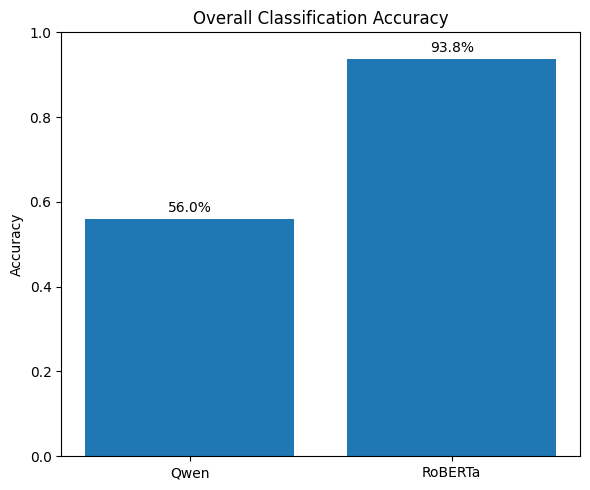

In [ ]:
import matplotlib.pyplot as plt


overall_accuracy_df = pd.DataFrame({
    "model": [
        "Qwen",
        "RoBERTa"
    ],

    "accuracy": [
        model_comparison_df[
            "qwen_correct"
        ].mean(),

        model_comparison_df[
            "roberta_correct"
        ].mean()
    ]
})


fig, ax = plt.subplots(
    figsize=(6, 5)
)


bars = ax.bar(
    overall_accuracy_df["model"],
    overall_accuracy_df["accuracy"]
)


ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "Overall Classification Accuracy"
)


ax.bar_label(
    bars,
    labels=[
        f"{value:.1%}"
        for value
        in overall_accuracy_df["accuracy"]
    ],
    padding=3
)


fig.tight_layout()


figure_path = (
    FIGURES_DIR /
    "qwen_vs_roberta_overall_accuracy.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
fold_comparison = (
    model_comparison_df
    .groupby("fold")
    .agg(
        qwen_accuracy=(
            "qwen_correct",
            "mean"
        ),

        roberta_accuracy=(
            "roberta_correct",
            "mean"
        )
    )
    .reset_index()
)


display(
    fold_comparison.round(4)
)

,fold,qwen_accuracy,roberta_accuracy
0,fold1,0.5188,0.8938
1,fold2,0.5875,0.9562
2,fold3,0.5750,0.9625
3,fold4,0.5188,0.9312
4,fold5,0.6000,0.9438


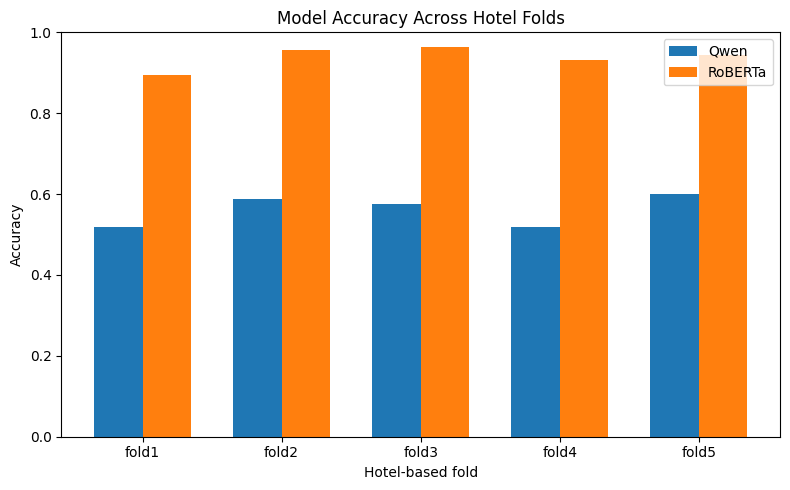

In [ ]:
x = np.arange(
    len(fold_comparison)
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(8, 5)
)


qwen_bars = ax.bar(
    x - width / 2,
    fold_comparison["qwen_accuracy"],
    width,
    label="Qwen"
)


roberta_bars = ax.bar(
    x + width / 2,
    fold_comparison["roberta_accuracy"],
    width,
    label="RoBERTa"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    fold_comparison["fold"]
)


ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_xlabel(
    "Hotel-based fold"
)

ax.set_title(
    "Model Accuracy Across Hotel Folds"
)

ax.legend()


fig.tight_layout()


figure_path = (
    FIGURES_DIR /
    "qwen_vs_roberta_accuracy_by_fold.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
class_recall_rows = []


for gold_label in [
    "truthful",
    "deceptive"
]:

    subset = model_comparison_df[
        model_comparison_df[
            "gold_label"
        ] == gold_label
    ]


    class_recall_rows.append({
        "class": gold_label,

        "Qwen":
            subset[
                "qwen_correct"
            ].mean(),

        "RoBERTa":
            subset[
                "roberta_correct"
            ].mean()
    })


class_recall_df = pd.DataFrame(
    class_recall_rows
)


display(
    class_recall_df.round(4)
)

,class,Qwen,RoBERTa
0,truthful,0.385,0.9225
1,deceptive,0.735,0.9525


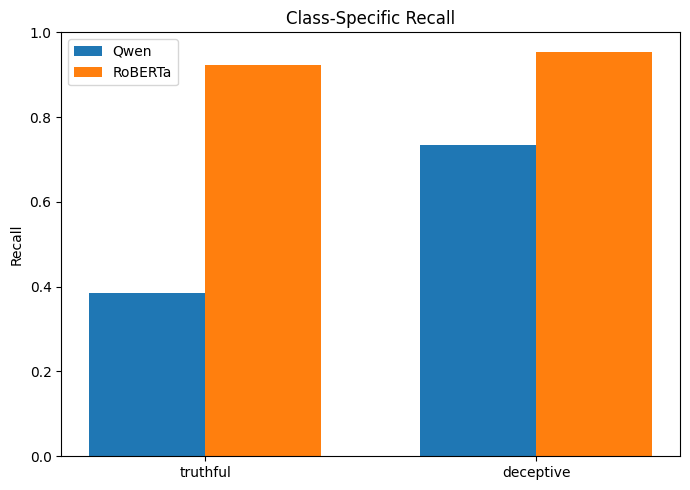

In [ ]:
x = np.arange(
    len(class_recall_df)
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(7, 5)
)


qwen_bars = ax.bar(
    x - width / 2,
    class_recall_df["Qwen"],
    width,
    label="Qwen"
)


roberta_bars = ax.bar(
    x + width / 2,
    class_recall_df["RoBERTa"],
    width,
    label="RoBERTa"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    class_recall_df["class"]
)


ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "Recall"
)

ax.set_title(
    "Class-Specific Recall"
)

ax.legend()


fig.tight_layout()


figure_path = (
    FIGURES_DIR /
    "qwen_vs_roberta_class_recall.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

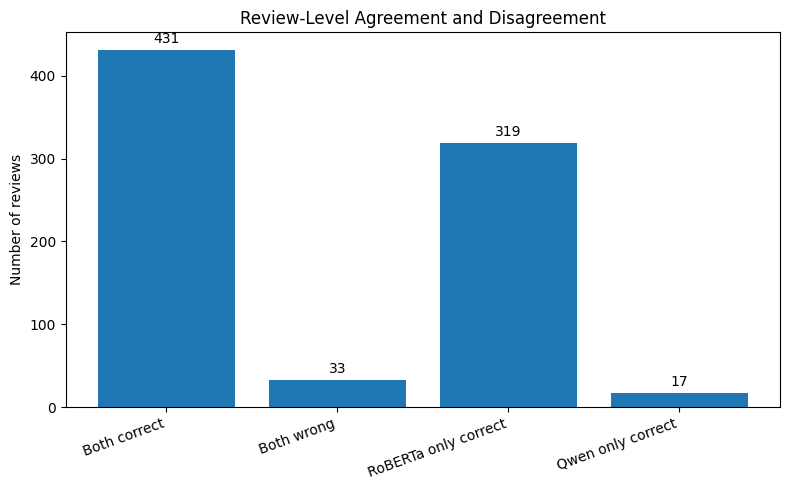

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)


bars = ax.bar(
    paired_summary["outcome"],
    paired_summary["count"]
)


ax.set_ylabel(
    "Number of reviews"
)

ax.set_title(
    "Review-Level Agreement and Disagreement"
)


ax.bar_label(
    bars,
    padding=3
)


plt.xticks(
    rotation=20,
    ha="right"
)


fig.tight_layout()


figure_path = (
    FIGURES_DIR /
    "qwen_vs_roberta_paired_outcomes.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

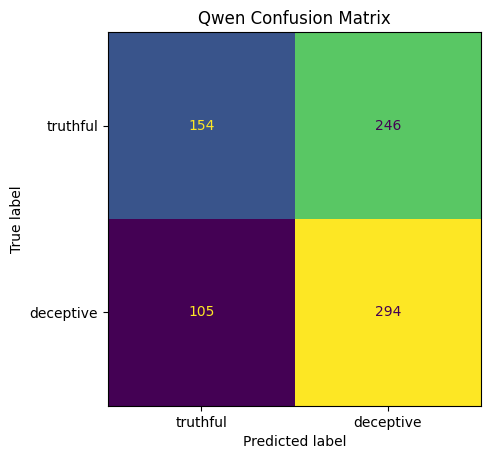

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


fig, ax = plt.subplots(
    figsize=(5, 5)
)


ConfusionMatrixDisplay.from_predictions(
    model_comparison_df["gold_label"],
    model_comparison_df["qwen_prediction"],
    labels=[
        "truthful",
        "deceptive"
    ],
    ax=ax,
    colorbar=False
)


ax.set_title(
    "Qwen Confusion Matrix"
)


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "qwen_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

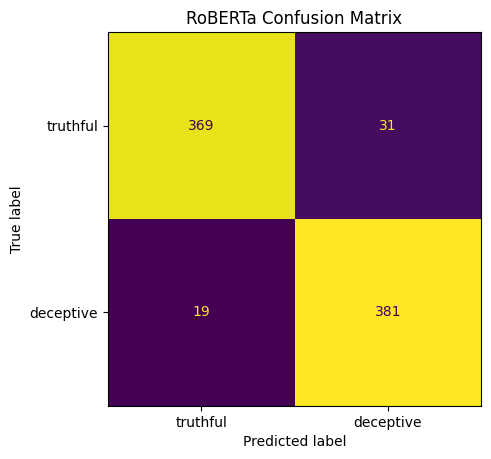

In [ ]:
fig, ax = plt.subplots(
    figsize=(5, 5)
)


ConfusionMatrixDisplay.from_predictions(
    model_comparison_df["gold_label"],
    model_comparison_df["roberta_prediction"],
    labels=[
        "truthful",
        "deceptive"
    ],
    ax=ax,
    colorbar=False
)


ax.set_title(
    "RoBERTa Confusion Matrix"
)


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "roberta_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 35. Error anlysis

In [ ]:
def assign_comparison_category(row):

    if (
        row["qwen_correct"]
        and
        row["roberta_correct"]
    ):
        return "both_correct"


    if (
        not row["qwen_correct"]
        and
        not row["roberta_correct"]
    ):
        return "both_wrong"


    if row["roberta_correct"]:
        return "roberta_only_correct"


    return "qwen_only_correct"


model_comparison_df[
    "comparison_category"
] = model_comparison_df.apply(
    assign_comparison_category,
    axis=1
)


print(
    model_comparison_df[
        "comparison_category"
    ].value_counts()
)

comparison_category
both_correct            431
roberta_only_correct    319
both_wrong               33
qwen_only_correct        17
Name: count, dtype: int64


In [ ]:
model_comparison_df = (
    model_comparison_df
    .merge(
        df_clean[
            [
                "review_id",
                "text",
                "hotel",
                "n_words",
                "n_characters"
            ]
        ],

        on="review_id",

        how="left",

        suffixes=(
            "",
            "_dataset"
        )
    )
)

In [ ]:
error_length_summary = (
    model_comparison_df
    .groupby(
        "comparison_category"
    )["n_words"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


display(
    error_length_summary.round(2)
)

,count,mean,median,std
comparison_category,,,,
both_correct,431,118.86,105.0,60.81
both_wrong,33,88.45,81.0,34.35
qwen_only_correct,17,107.59,104.0,41.88
roberta_only_correct,319,124.06,108.0,72.03


In [ ]:
hotel_performance = (
    model_comparison_df
    .groupby("hotel")
    .agg(
        n_reviews=(
            "review_id",
            "count"
        ),

        qwen_accuracy=(
            "qwen_correct",
            "mean"
        ),

        roberta_accuracy=(
            "roberta_correct",
            "mean"
        )
    )
    .reset_index()
)


hotel_performance[
    "accuracy_difference"
] = (
    hotel_performance[
        "roberta_accuracy"
    ]
    -
    hotel_performance[
        "qwen_accuracy"
    ]
)


display(
    hotel_performance
    .sort_values(
        "roberta_accuracy"
    )
    .round(4)
)

,hotel,n_reviews,qwen_accuracy,roberta_accuracy,accuracy_difference
11,james,40,0.450,0.850,0.400
0,affinia,40,0.500,0.900,0.400
13,monaco,40,0.675,0.900,0.225
7,hilton,40,0.450,0.900,0.450
15,palmer,40,0.675,0.900,0.225
16,sheraton,40,0.600,0.900,0.300
17,sofitel,40,0.500,0.925,0.425
8,homewood,40,0.600,0.925,0.325
10,intercontinental,40,0.525,0.950,0.425
9,hyatt,40,0.475,0.950,0.475


In [ ]:
shared_errors_df = (
    model_comparison_df[
        model_comparison_df[
            "comparison_category"
        ] == "both_wrong"
    ]
    .copy()
)


print(
    "Shared errors:",
    len(shared_errors_df)
)


display(
    shared_errors_df[
        [
            "review_id",
            "gold_label",
            "qwen_prediction",
            "roberta_prediction",
            "hotel",
            "n_words",
            "text"
        ]
    ].head(10)
)

Shared errors: 33


,review_id,gold_label,qwen_prediction,roberta_prediction,hotel,n_words,text
2,R0242,truthful,deceptive,deceptive,james,116,"I stayed at the James in June, and I must say,..."
4,R0244,truthful,deceptive,deceptive,james,191,I found this wonderful Hotel ! The location is...
24,R0264,truthful,deceptive,deceptive,sofitel,89,On a recent trip to Chicago to attend a major ...
25,R0265,truthful,deceptive,deceptive,monaco,50,A friend highly recommended this hotel and we ...
34,R0274,truthful,deceptive,deceptive,james,61,"Dispite what other are saying, this was one, i..."
40,R0280,truthful,deceptive,deceptive,hilton,140,My family and I have just had a two week holid...
56,R0296,truthful,deceptive,deceptive,james,60,I have stayed at many hotels traveling for bot...
64,R0304,truthful,deceptive,deceptive,sofitel,66,Striking architecture is only the beginning of...
97,R0657,deceptive,truthful,truthful,hilton,66,I stayed here for a weekend while visiting som...
113,R0673,deceptive,truthful,truthful,hilton,85,My husband and I stayed in the Hilton Chicago ...


In [ ]:
MODEL_COMPARISON_PATH = (
    RESULTS_DIR /
    "qwen_roberta_review_level_comparison.csv"
)


model_comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)


print(
    "Comparison dataset saved at:"
)

print(
    MODEL_COMPARISON_PATH
)

Comparison dataset saved at:
/content/drive/MyDrive/HLT_project/results/qwen_roberta_review_level_comparison.csv


## 36. Task-specific supervised RoBERTa vs general-purpose zero-shot Qwen— Summary

The two automatic systems showed substantially different performance on the same 800 hotel reviews.

### Overall performance

- **Qwen zero-shot accuracy:** 56.0%
- **RoBERTa out-of-fold accuracy:** 93.75%
- **Accuracy difference:** +37.75 percentage points in favor of RoBERTa

RoBERTa also showed substantially more balanced class-specific performance. Its recall was 92.25% for truthful reviews and 95.25% for deceptive reviews, whereas Qwen showed a strong asymmetry, with substantially higher recall for deceptive than truthful reviews.

### Paired comparison

Because both systems classified exactly the same reviews, their correctness was compared at the individual-review level:

- both correct: 431 reviews
- both incorrect: 33 reviews
- only RoBERTa correct: 319 reviews
- only Qwen correct: 17 reviews

Among the 336 reviews for which the models differed in correctness, RoBERTa was correct in 94.9% of cases.

An exact McNemar test confirmed a strong paired difference between the systems (p = 2.49 × 10⁻73).

### Interpretation

These results show that a task-specific supervised classifier can exploit the linguistic regularities of this corpus much more effectively than the evaluated general-purpose zero-shot LLM.

However, this comparison should not be interpreted as evidence that RoBERTa is generally superior to Qwen for deception detection. The systems operate under different learning conditions: RoBERTa was explicitly fine-tuned on labeled examples from the corpus, whereas Qwen received no task-specific training.

Furthermore, performance is specific to the Positive Deceptive Opinion Spam Corpus, in which deception labels are confounded with review source. High classification accuracy may therefore partly reflect corpus-specific collection artifacts rather than general linguistic markers of deception.